In [ ]:
import os
import zipfile
import kagglehub
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
base_path = kagglehub.competition_download('dogs-vs-cats')
print(f"Downloaded zip file at: {base_path}")

train_zip = os.path.join(base_path, 'train.zip')

print("Unzipping train.zip...")

os.makedirs('data', exist_ok=True)

with zipfile.ZipFile(train_zip, 'r') as zip_ref:
    zip_ref.extractall('data')

print("Done")


100%|██████████| 812M/812M [00:07<00:00, 109MB/s] 

Extracting files...


Downloaded zip file at: /root/.cache/kagglehub/competitions/dogs-vs-cats
Unzipping train.zip...
Done


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


In [3]:
from torchvision import datasets,models,transforms
from torch.utils.data import DataLoader, Dataset,ConcatDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, glob, copy, random
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay


In [4]:
lr =1e-3
batch_size=64
epochs = 25
dropout_rate=0.4
num_workers=2


In [5]:
device="cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

torch.manual_seed(1234)
if device == 'cuda':
    torch.cuda.manual_seed_all(1234)

Device: cuda


In [6]:
# Load labeled training images only. The Kaggle unlabeled test images are not used,
# so train/val/test are all split from train.zip for metric calculation.
train_dir = 'data/train'
import glob

all_image_list = sorted(glob.glob(os.path.join(train_dir, '*.jpg')))

print(f"Labeled images from train.zip: {len(all_image_list)}")


Labeled images from train.zip: 25000


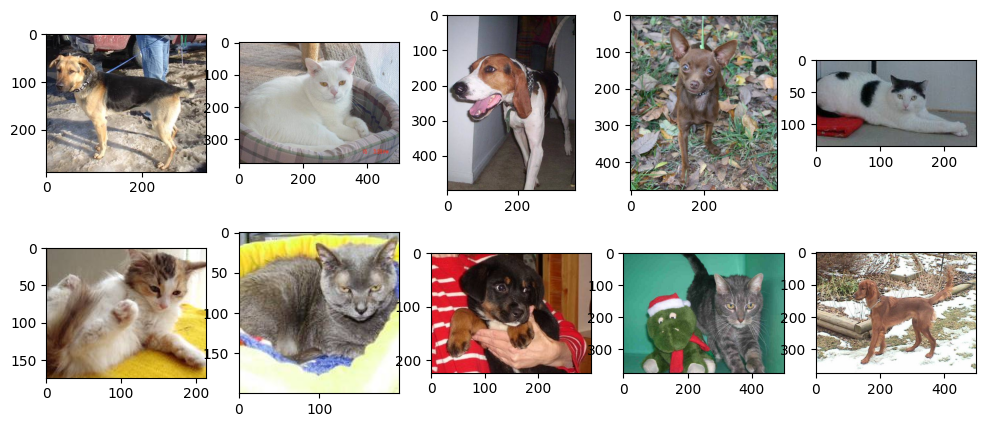

In [7]:
random_idx = np.random.randint(0, len(all_image_list), size=10)

fig = plt.figure(figsize=(12,5))
for i, idx in enumerate(random_idx, start=1):
    ax = fig.add_subplot(2,5,i)
    img = Image.open(all_image_list[idx])
    plt.imshow(img)
    ax.axis=('off')

plt.show()


In [8]:
all_image_list[0].split('/')[-1].split('.')[0]


'cat'

In [9]:
normalize=transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])

train_transforms =transforms.Compose([
    transforms.Resize((256,256)), # zoom a bit first
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)), # then crop randomly to 224, adjust scale to be less aggressive (lower bound =0.7 of the initial area instead of default 0.08)
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    normalize
])


# remember to remove the crop & flip part, only use challenges to train, test data must be original
val_transforms  =transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize
])


# same as the above
test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize
])




In [10]:
class CatDogDataset(torch.utils.data.Dataset):
    def __init__(self,file_list,transform = None):
        self.file_list=file_list
        self.transform=transform

    def __len__(self):
        self.filelength =len(self.file_list)
        return self.filelength

    def __getitem__(self,idx):
        img_path =self.file_list[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)

        label = img_path.split('/')[-1].split('.')[0]
        if label == 'dog':
            label=1
        elif label == 'cat':
            label=0

        return img,label


In [11]:
labels = [os.path.basename(path).split('.')[0] for path in all_image_list]

# First split: 80% train, 20% holdout. Second split: holdout into 10% val and 10% test.
train_list, holdout_list = train_test_split(
    all_image_list,
    test_size=0.2,
    random_state=36,
    stratify=labels,
)

holdout_labels = [os.path.basename(path).split('.')[0] for path in holdout_list]
val_list, test_list = train_test_split(
    holdout_list,
    test_size=0.5,
    random_state=36,
    stratify=holdout_labels,
)

print(f"Train images: {len(train_list)}")
print(f"Validation images: {len(val_list)}")
print(f"Test images: {len(test_list)}")


Train images: 20000
Validation images: 2500
Test images: 2500


In [12]:
train_data = CatDogDataset(train_list, transform=train_transforms)
val_data = CatDogDataset(val_list, transform=val_transforms)
test_data = CatDogDataset(test_list, transform=test_transforms)


In [13]:
train_loader = torch.utils.data.DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader = torch.utils.data.DataLoader(dataset=val_data, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader = torch.utils.data.DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)


In [14]:
print(f"train batches: {len(train_loader)}, val batches: {len(val_loader)}, test batches: {len(test_loader)}")


train batches: 313, val batches: 40, test batches: 40


In [15]:
train_data[0][0].shape

torch.Size([3, 224, 224])

In [16]:
class Cnn(nn.Module):
  def __init__(self, dropout_rate=0.4):
    super().__init__()
    self.block1=self._conv_block(3,32)
    self.block2=self._conv_block(32,64)
    self.block3=self._conv_block(64,128)
    self.block4=self._conv_block(128,256)

    self.gap=nn.AdaptiveAvgPool2d(1)

    self.fc1=nn.Linear(256,128)
    self.dropout=nn.Dropout(dropout_rate)
    self.fc2=nn.Linear(128,2)
  @staticmethod
  def _conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2)
    )
  def forward(self, x):
    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)
    x = self.block4(x)
    x = self.gap(x)
    x = x.flatten(1)
    x=F.relu(self.fc1(x))
    x=self.dropout(x)
    x=self.fc2(x)
    return x


In [17]:
model = Cnn(dropout_rate=dropout_rate).to(device)
optimizer = optim.Adam(params = model.parameters(), lr=lr, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

scheduler=optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

n_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {n_params:,}")
print(model)


Total trainable parameters: 1,207,330
Cnn(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0,

In [18]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
best_state   = None

for epoch in range(epochs):
    # -------- Train --------
    model.train()
    epoch_loss, epoch_acc = 0.0, 0.0
    for data, label in train_loader:
        data, label = data.to(device), label.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() / len(train_loader)                            # .item() detaches
        epoch_acc  += (output.argmax(1) == label).float().mean().item() / len(train_loader)

    # -------- Validate --------
    model.eval()
    val_loss, val_acc = 0.0, 0.0
    with torch.no_grad():
        for data, label in val_loader:
            data, label = data.to(device), label.to(device)
            output = model(data)
            loss = criterion(output, label)
            val_loss += loss.item() / len(val_loader)
            val_acc  += (output.argmax(1) == label).float().mean().item() / len(val_loader)

    # -------- Bookkeeping --------
    history['train_loss'].append(epoch_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(epoch_acc)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        marker = "  <-- best"
    else:
        marker = ""

    print(f"Epoch {epoch+1:2d}/{epochs} | "
          f"train loss {epoch_loss:.4f} acc {epoch_acc:.4f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
          f"lr {current_lr:.1e}{marker}")

# Restore the best weights
model.load_state_dict(best_state)
print(f"\nBest val accuracy: {best_val_acc:.4f}")

Epoch  1/25 | train loss 0.6228 acc 0.6580 | val loss 0.6955 acc 0.6449 | lr 1.0e-03  <-- best
Epoch  2/25 | train loss 0.5701 acc 0.7108 | val loss 0.5859 acc 0.7129 | lr 1.0e-03  <-- best
Epoch  3/25 | train loss 0.5272 acc 0.7458 | val loss 0.5562 acc 0.7133 | lr 1.0e-03  <-- best
Epoch  4/25 | train loss 0.4881 acc 0.7728 | val loss 0.4590 acc 0.8023 | lr 1.0e-03  <-- best
Epoch  5/25 | train loss 0.4364 acc 0.8045 | val loss 0.4296 acc 0.8055 | lr 1.0e-03  <-- best
Epoch  6/25 | train loss 0.3925 acc 0.8313 | val loss 1.3873 acc 0.5906 | lr 1.0e-03
Epoch  7/25 | train loss 0.3418 acc 0.8532 | val loss 0.4747 acc 0.7875 | lr 1.0e-03
Epoch  8/25 | train loss 0.3027 acc 0.8745 | val loss 0.5792 acc 0.7746 | lr 5.0e-04
Epoch  9/25 | train loss 0.2387 acc 0.9033 | val loss 0.2122 acc 0.9109 | lr 5.0e-04  <-- best
Epoch 10/25 | train loss 0.2205 acc 0.9134 | val loss 0.2182 acc 0.9117 | lr 5.0e-04  <-- best
Epoch 11/25 | train loss 0.2063 acc 0.9166 | val loss 0.1892 acc 0.9258 | lr 5.0

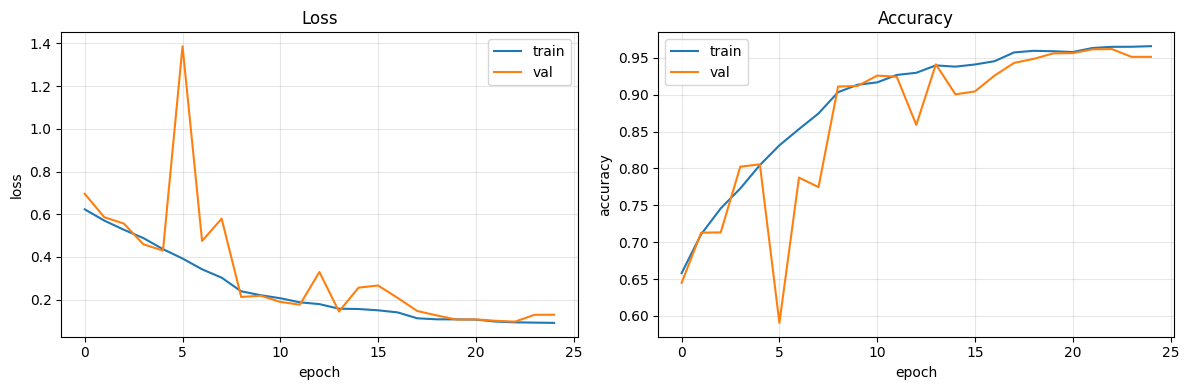

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'],   label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].set_title('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='train')
axes[1].plot(history['val_acc'],   label='val')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('accuracy'); axes[1].set_title('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

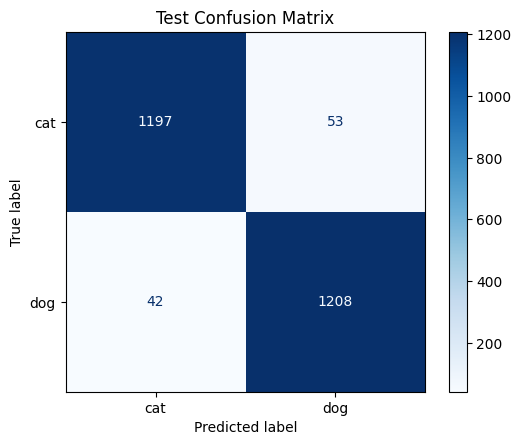

              precision    recall  f1-score   support

         cat     0.9661    0.9576    0.9618      1250
         dog     0.9580    0.9664    0.9622      1250

    accuracy                         0.9620      2500
   macro avg     0.9620    0.9620    0.9620      2500
weighted avg     0.9620    0.9620    0.9620      2500



In [20]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for data, label in test_loader:
        data = data.to(device)
        preds = model(data).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(label.numpy())

cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['cat', 'dog'])
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=True)
ax.set_title('Test Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=['cat', 'dog'], digits=4))


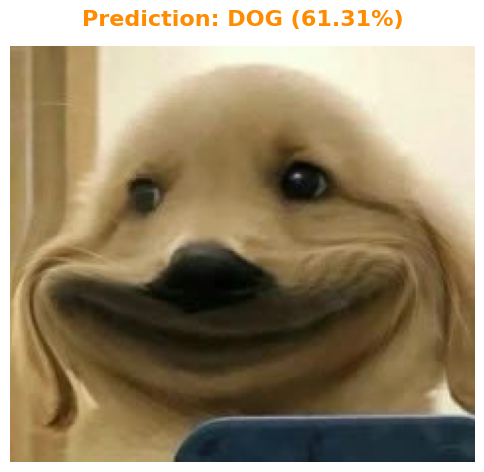

In [ ]:
def predict_and_show_image(image_path, model, device):
    model.eval()
    infer_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        normalize,
    ])

    img_original = Image.open(image_path).convert('RGB')
    img_tensor   = infer_transform(img_original).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs  = F.softmax(output, dim=1)[0]
        cat_prob, dog_prob = probs[0].item() * 100, probs[1].item() * 100

    if dog_prob > cat_prob:
        label, confidence = "DOG", dog_prob
    else:
        label, confidence = "CAT", cat_prob

    plt.figure(figsize=(6, 6))
    plt.imshow(img_original)
    color = 'green' if confidence > 80.0 else 'darkorange'
    plt.title(f"Prediction: {label} ({confidence:.2f}%)",
              fontsize=16, fontweight='bold', color=color, pad=15)
    plt.axis('off'); plt.show()

# Example:
# predict_and_show_image("thong.jpg", model, device)
